In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils.plotting import plot_hists

In [ ]:
def simulate_stochastic_vdp(mu=1.0, sigma=0.1, dt=0.01, total_time=50.0, initial_state=[0.1, 0.0], nu=0.0):
    """Simulates the Stochastic Van der Pol Oscillator using Euler-Maruyama."""
    
    num_steps = int(total_time / dt)
    
    x = np.zeros(num_steps)
    v = np.zeros(num_steps)
    err = np.zeros(num_steps)
    x[0], v[0] = initial_state
    
    dW1 = np.random.normal(0, 1, num_steps) * np.sqrt(dt)
    dW2 = np.random.normal(0, 1, num_steps) * np.sqrt(dt)
    
    for k in range(num_steps - 1):
        v[k+1] = v[k] + (mu * (1 - x[k]**2) * v[k] - x[k] + err[k]) * dt + sigma * dW2[k]
        x[k+1] = x[k] + v[k+1] * dt + sigma * dW1[k]
        err[k+1] = err[k] + nu * v[k+1]**2
        
    return x, v


def sample_trajectories(n_trajs, T=1000, mu=1.0, sigma=0.05, dt=0.01, nu=0.0):
    """Sample multiple trajectories -> (n_trajs, T, 2)."""
    trajs = []
    for _ in range(n_trajs):
        x0 = np.random.uniform(-1, 1, 2)
        x, v = simulate_stochastic_vdp(mu=mu, sigma=sigma, dt=dt,
                                        total_time=T*dt, initial_state=x0, nu=nu)
        trajs.append(np.column_stack([x, v]))
    return np.array(trajs)


def sample_dataset(n_trajs=100, anomaly_frac=0.3, nu_anomalous=1e-5, **kwargs):
    """Generate labeled dataset -> (x, y) in project format."""
    n_anom = int(n_trajs * anomaly_frac)
    n_normal = n_trajs - n_anom
    x_normal = sample_trajectories(n_normal, nu=0.0, **kwargs)
    x_anom = sample_trajectories(n_anom, nu=nu_anomalous, **kwargs)
    x = np.concatenate([x_normal, x_anom])
    y = np.array([False]*n_normal + [True]*n_anom)
    return x, y


def _detect_failures(x_all, xlim, vlim):
    """Detect failure timestep per trajectory. Returns (n_trajs,) array, -1 = success."""
    fail = np.full(len(x_all), -1)
    for i in range(len(x_all)):
        exceeded = np.where(
            (np.abs(x_all[i, :, 0]) > xlim) | (np.abs(x_all[i, :, 1]) > vlim)
        )[0]
        if len(exceeded) > 0:
            fail[i] = exceeded[0]
    return fail


def load_vdp_experiment(
    n_trajs=500,
    anomaly_frac=0.3,
    nu_anomalous=1e-4,
    T=5000,
    win=1000,
    hor=500,
    xlim=3.0,
    vlim=3.0,
    train_frac=0.6,
    normalize=False,
    **sim_kwargs,
):
    """Generate a VDP failure prediction dataset.

    Simulates normal (nu=0) and anomalous (nu=nu_anomalous) trajectories,
    then splits into train/test following the same protocol as load_experiment.

    Failure is defined as the first timestep where |x| > xlim or |v| > vlim.
    Normal trajectories are asserted to never fail (raises if they do).
    Anomalous trajectories that never exceed bounds are dropped, since
    they are indistinguishable from normal data.

    Returns (x_train, x_test, y_true) where:
        x_train: (N_train, T, 2) success-only full trajectories
        x_test:  (N_test, win, 2) windowed test episodes
        y_true:  (N_test,) bool — True if failure within horizon
    """
    from data.processing import normalize_channels
    from utils.windows import sample_test_windows

    n_anom = int(n_trajs * anomaly_frac)
    n_normal = n_trajs - n_anom
    x_normal = sample_trajectories(n_normal, T=T, nu=0.0, **sim_kwargs)
    x_anom = sample_trajectories(n_anom, T=T, nu=nu_anomalous, **sim_kwargs)

    # Assert no normal trajectory exceeds bounds
    fail_normal = _detect_failures(x_normal, xlim, vlim)
    n_failed_normal = (fail_normal >= 0).sum()
    assert n_failed_normal == 0, (
        f"{n_failed_normal}/{n_normal} normal trajectories exceed bounds "
        f"(xlim={xlim}, vlim={vlim}). Increase limits or decrease sigma."
    )

    # Drop anomalous trajectories that never fail
    fail_anom = _detect_failures(x_anom, xlim, vlim)
    actually_failed = fail_anom >= 0
    n_dropped = (~actually_failed).sum()
    if n_dropped > 0:
        print(f"Dropped {n_dropped}/{n_anom} anomalous trajectories that never exceeded bounds.")
    x_anom = x_anom[actually_failed]
    fail_anom = fail_anom[actually_failed]

    x_all = np.concatenate([x_normal, x_anom])
    fail = np.concatenate([fail_normal, fail_anom])

    split = int(len(x_all) * train_frac)
    x_tr = x_all[:split][fail[:split] == -1]
    x_te, fail_te = x_all[split:], fail[split:]

    if normalize:
        _, x_tr, x_te = normalize_channels(x_tr, x_te)

    x_test, y_true, _ = sample_test_windows(x_te, fail_te, window=win, horizon=hor)

    return x_tr, x_test, y_true

In [3]:
x_tr, x_te, y_true = load_vdp_experiment(win=2000, hor=200)
x_tr.shape, x_te.shape, y_true.shape

((300, 5000, 2), (110, 2000, 2), (110,))

In [4]:
y_true.mean()

np.float64(0.5454545454545454)

In [5]:
x_te.min(), x_te.max()

(np.float64(-2.856257197336064), np.float64(2.999006372917642))

(-3.0, 3.0)

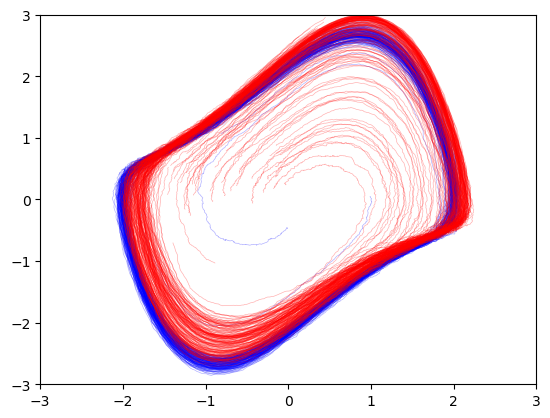

In [6]:
plt.plot(*x_te[~y_true].T, alpha=0.3, color='blue', linewidth=0.5)
plt.plot(*x_te[y_true].T, alpha=0.3, color='red', linewidth=0.5);
plt.xlim(-3, 3)
plt.ylim(-3, 3)

In [8]:
def plot_3d_density(samples: np.ndarray):
    from scipy.stats import gaussian_kde

    kde = gaussian_kde(samples.T)  # expects (2, N)

    x = np.linspace(samples[:, 0].min(), samples[:, 0].max(), 100)
    y = np.linspace(samples[:, 1].min(), samples[:, 1].max(), 100)
    X, Y = np.meshgrid(x, y)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)

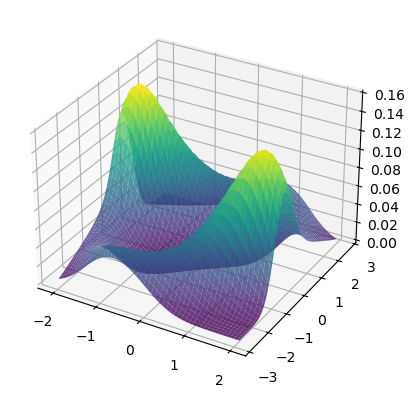

In [12]:
plot_3d_density(x_te[~y_true][10])

In [671]:
x.shape

(1000, 2)

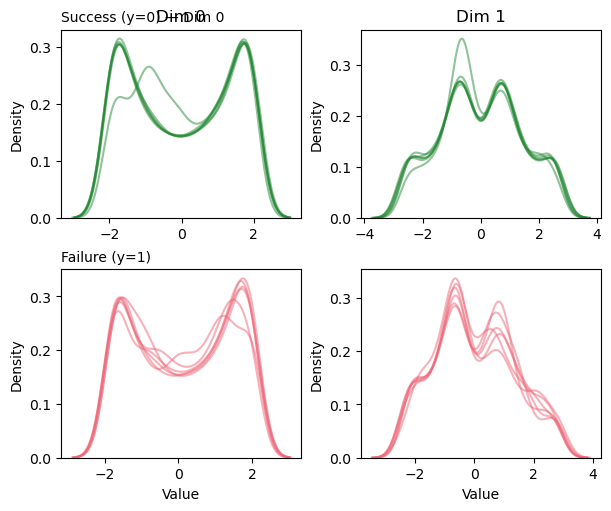

In [13]:
plot_hists(x_te, y_true);

In [14]:
from detectors.rff_mean import RFFMeanDetector

In [15]:
x_tr.shape

(300, 5000, 2)

In [16]:
model = RFFMeanDetector(reg=1e-5).fit(x_tr)

In [17]:
y_score = model.score_samples(x_te)

0.9943333333333333

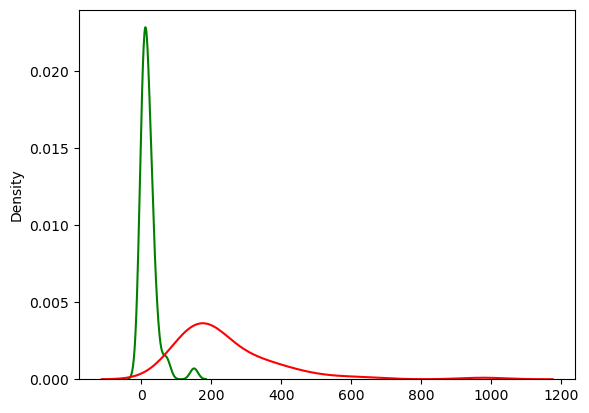

In [18]:
sns.kdeplot(y_score[~y_true], color='green')
sns.kdeplot(y_score[y_true], color='red')
from sklearn.metrics import roc_auc_score
roc_auc_score(y_true, y_score)